<a href="https://colab.research.google.com/github/MariyaAlshamrani/Bookstore/blob/main/phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import numpy as np
import os
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/leenmq05/Xxxx/e26d89f2d5a15177f3b20571bf00e85b3219b78a/updated_pollution_dataset.csv")


# **Data Analysis**

**Five number summary :**

 Is a simple way to describe the dataset using five key values that summarize its distribution.



-Min: The minimum value in the dataset.

-First Quartile (Q1) : indicating that 25% of the data values lie below this point

-Median (50%) : The middle value that divides the dataset into two equal halves.

-Third Quartile (Q3) :  indicating that 75% of the data values fall below this value

-Max: The maximum value in the dataset.


In [ ]:

summary = df.describe()[['Temperature','Humidity','PM2.5','PM10','NO2','SO2','CO','Proximity_to_Industrial_Areas','Population_Density']].T

five_number_summary = summary[['min', '25%', '50%', '75%', 'max']]

print("Five number summary for numeric attributes:")
print(five_number_summary)


Five number summary for numeric attributes:
                                  min     25%     50%      75%     max
Temperature                     13.40   25.10   29.00   34.000   58.60
Humidity                        36.00   58.30   69.80   80.300  128.10
PM2.5                            0.00    4.60   12.00   26.100  295.00
PM10                            -0.20   12.30   21.70   38.100  315.80
NO2                              7.40   20.10   25.30   31.900   64.90
SO2                             -6.20    5.10    8.00   13.725   44.90
CO                               0.65    1.03    1.41    1.840    3.72
Proximity_to_Industrial_Areas    2.50    5.40    7.90   11.100   25.80
Population_Density             188.00  381.00  494.00  600.000  957.00



| Attribute                     |  Min   |  25%   |  50%   |  75%   |  Max   |
|-------------------------------|--------|--------|--------|--------|--------|
| Temperature                   | 13.40  | 25.10  | 29.00  | 34.00  | 58.60  |
| Humidity                      | 36.00  | 58.30  | 69.80  | 80.30  |128.10  |
| PM2.5                         |  0.00  |  4.60  | 12.00  | 26.10  |295.00  |
| PM10                          | -0.20  | 12.30  | 21.70  | 38.10  |315.80  |
| NO2                           |  7.40  | 20.10  | 25.30  | 31.90  | 64.90  |
| SO2                           | -6.20  |  5.10  |  8.00  |13.725  | 44.90  |
| CO                            |  0.65  |  1.03  |  1.41  |  1.84  |  3.72  |
| Proximity_to_Industrial_Areas|  2.50  |  5.40  |  7.90  | 11.10  | 25.80  |
| Population_Density            |188.00  |381.00  |494.00  |600.00  |957.00  |



**Detecting Outliers**


In [ ]:

numeric_df = df.select_dtypes(include=['number'])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1


outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR)))
outlier_counts = outliers.sum()

print("Outlier counts per column:\n")
print(outlier_counts)


Outlier counts per column:

Temperature                       72
Humidity                          19
PM2.5                            352
PM10                             324
NO2                               73
SO2                              124
CO                                45
Proximity_to_Industrial_Areas     16
Population_Density                 7
dtype: int64


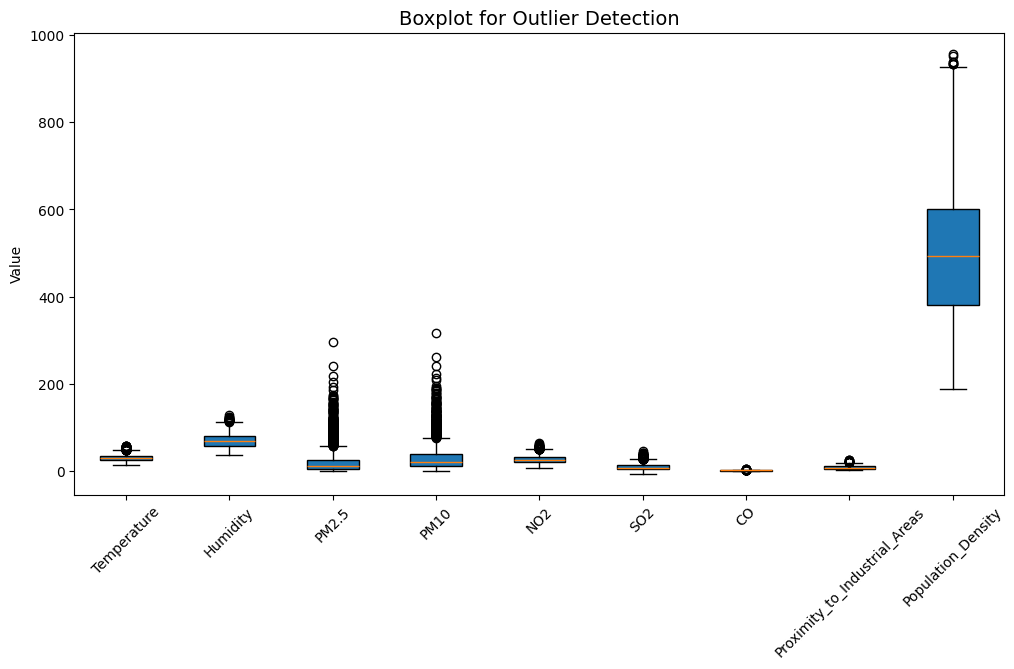

In [ ]:

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 6))
plt.boxplot(numeric_df, tick_labels=numeric_df.columns, patch_artist=True)

plt.title("Boxplot for Outlier Detection", fontsize=14)
plt.ylabel("Value")
plt.xticks(rotation=45)

plt.show()

The boxplot analysis shows that several numeric attributes in the dataset contain noticeable outliers, especially the PM2.5, PM10, and SO2 columns, which have extremely high counts of outlier values (352, 324, and 124 respectively). These outliers appear as individual points outside the whiskers of the boxplots, indicating that some measurements are significantly higher or lower than the rest of the data. Attributes like Temperature, NO2, and CO also show moderate levels of outliers, while Humidity, Proximity_to_Industrial_Areas, and Population_Density are relatively more stable. The presence of these outliers highlights the need for preprocessing because they can distort the mean and standard deviation, leading to misleading statistical summaries.

Therefore, preprocessing techniques such as normalization and others are essential to make the dataset more consistent, reliable, and suitable for predictive modeling.



 **Class** **Imbalance** **Detection**

***Class*** **label**:


---












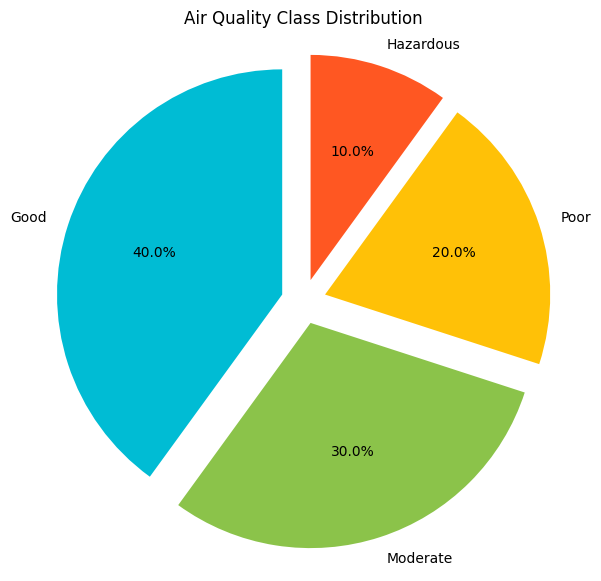

In [ ]:
class_counts = df['Air Quality'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#00bcd4', '#8bc34a', '#ffc107', '#ff5722', '#9c27b0'],
    explode=[0.1] * len(class_counts)
)
plt.title('Air Quality Class Distribution')
plt.axis('equal')
plt.show()

The dataset is imbalanced, as the “Hazardous” class has far fewer samples compared to “Good”. This pie chart shows the distribution of air quality categories, where some categories, like “Moderate,” appear much more frequently than others, indicating class imbalance that could bias the model.




**For** **Numeric** **Variables**:


---



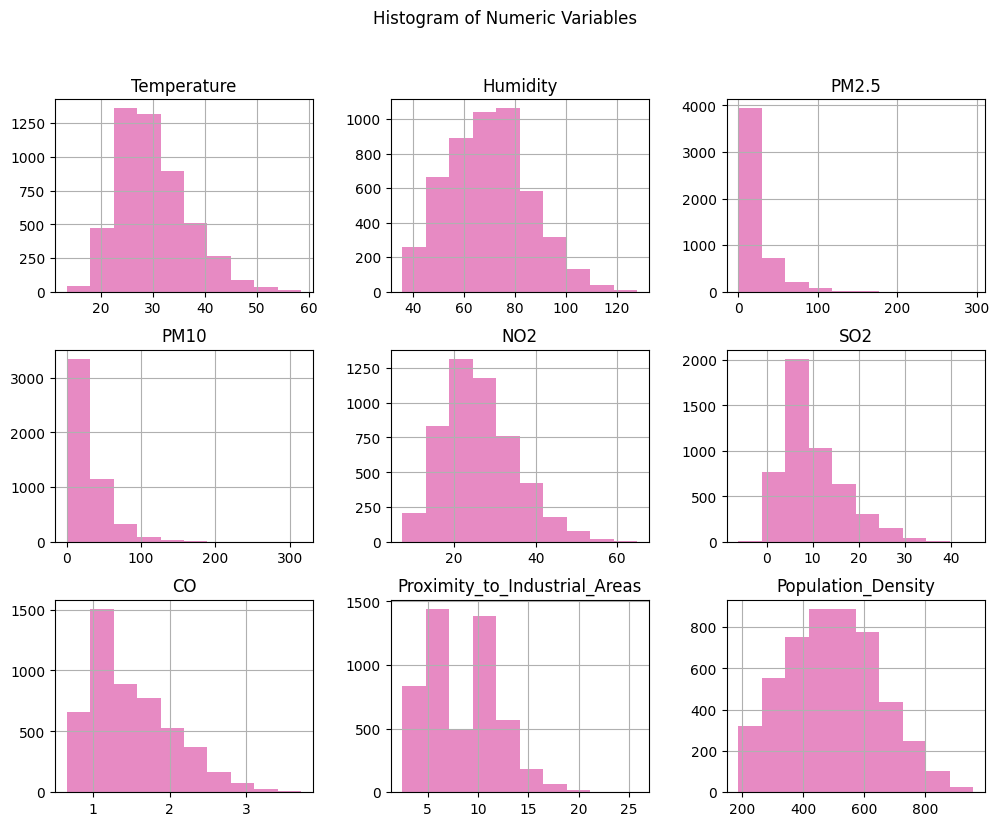

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(12, 9), color='#e78ac3')
plt.suptitle('Histogram of Numeric Variables')
plt.show()

In [ ]:
from imblearn.over_sampling import RandomOverSampler

X = df.drop(columns=['Air Quality'])
y = df['Air Quality']

ran = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ran.fit_resample(X, y)

df_resampled = pd.concat([X_resampled, y_resampled])

print (df_resampled['Air Quality'].value_counts())

Air Quality
Moderate     2000
Good         2000
Hazardous    2000
Poor         2000
Name: count, dtype: int64



# **Data Representation**
The visualization of data through graphical methods facilitates a deeper understanding of underlying patterns and relationships within datasets. In this analysis, scatter plots, line plots, and box plots were employed to effectively illustrate data distributions and trends.


---


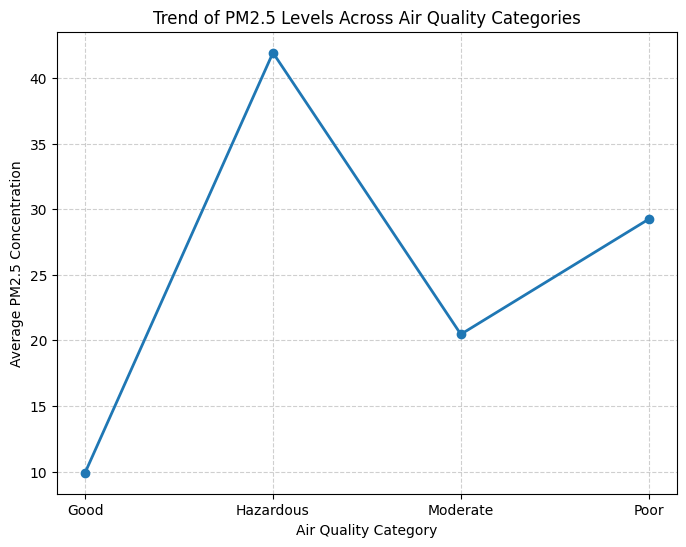

In [ ]:
pm25_by_air_quality = df.groupby('Air Quality')['PM2.5'].mean()
plt.figure(figsize=(8,6))
plt.plot(pm25_by_air_quality.index, pm25_by_air_quality.values,
         marker='o', color='#1f77b4', linewidth=2)
plt.xlabel("Air Quality Category")
plt.ylabel("Average PM2.5 Concentration")
plt.title("Trend of PM2.5 Levels Across Air Quality Categories")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

This line plot shows the trend of average PM2.5 concentrations across different air quality categories.
It visually emphasizes how pollution levels increase or decrease depending on air quality.
This helps confirm that PM2.5 strongly affects the air quality label and supports using it as an important feature.


---



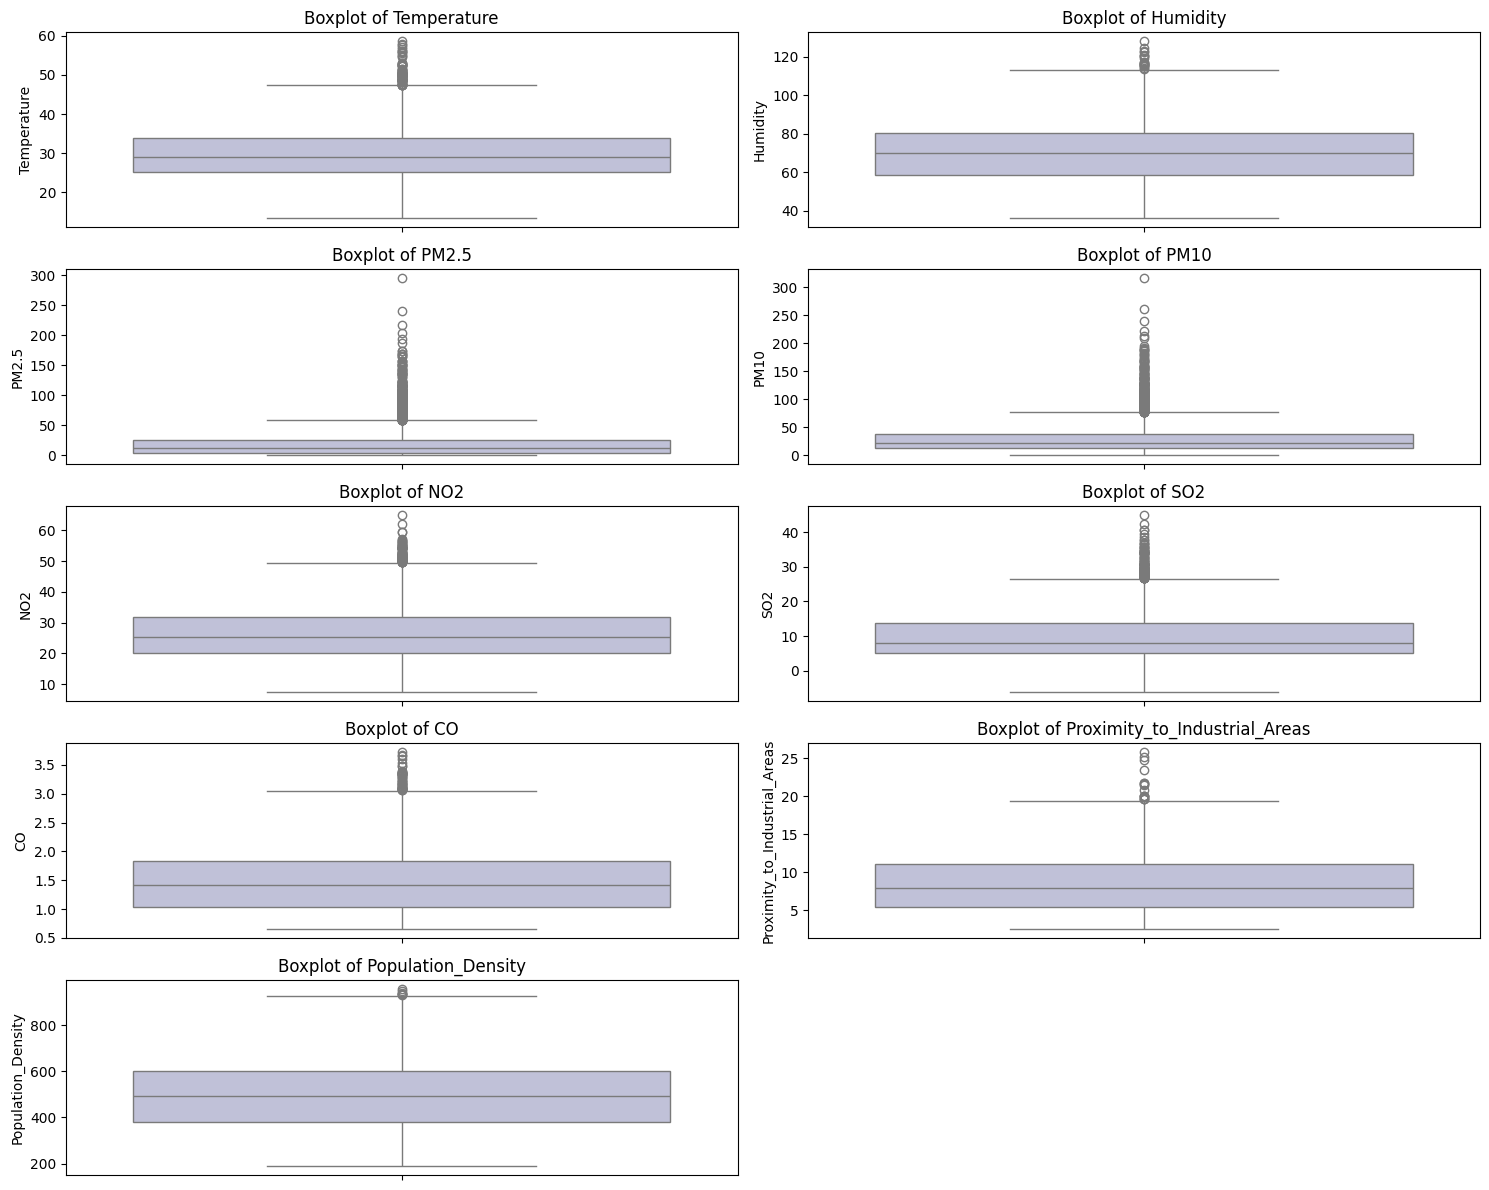

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot((len(numeric_cols) + 1) // 2, 2, i)
    sns.boxplot(y=df[col], color='#bcbddc')
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

The boxplots reveal interesting patterns in the dataset. Most air pollutants (PM2.5, PM10, NO2, SO2, CO) are skewed to the right, with some extreme values in highly polluted areas. Temperature and humidity also show high-end outliers, suggesting occasional extreme weather. Industrial proximity varies widely, with outliers spread across different distances, whereas population density has outliers concentrated in the most crowded cities.


---



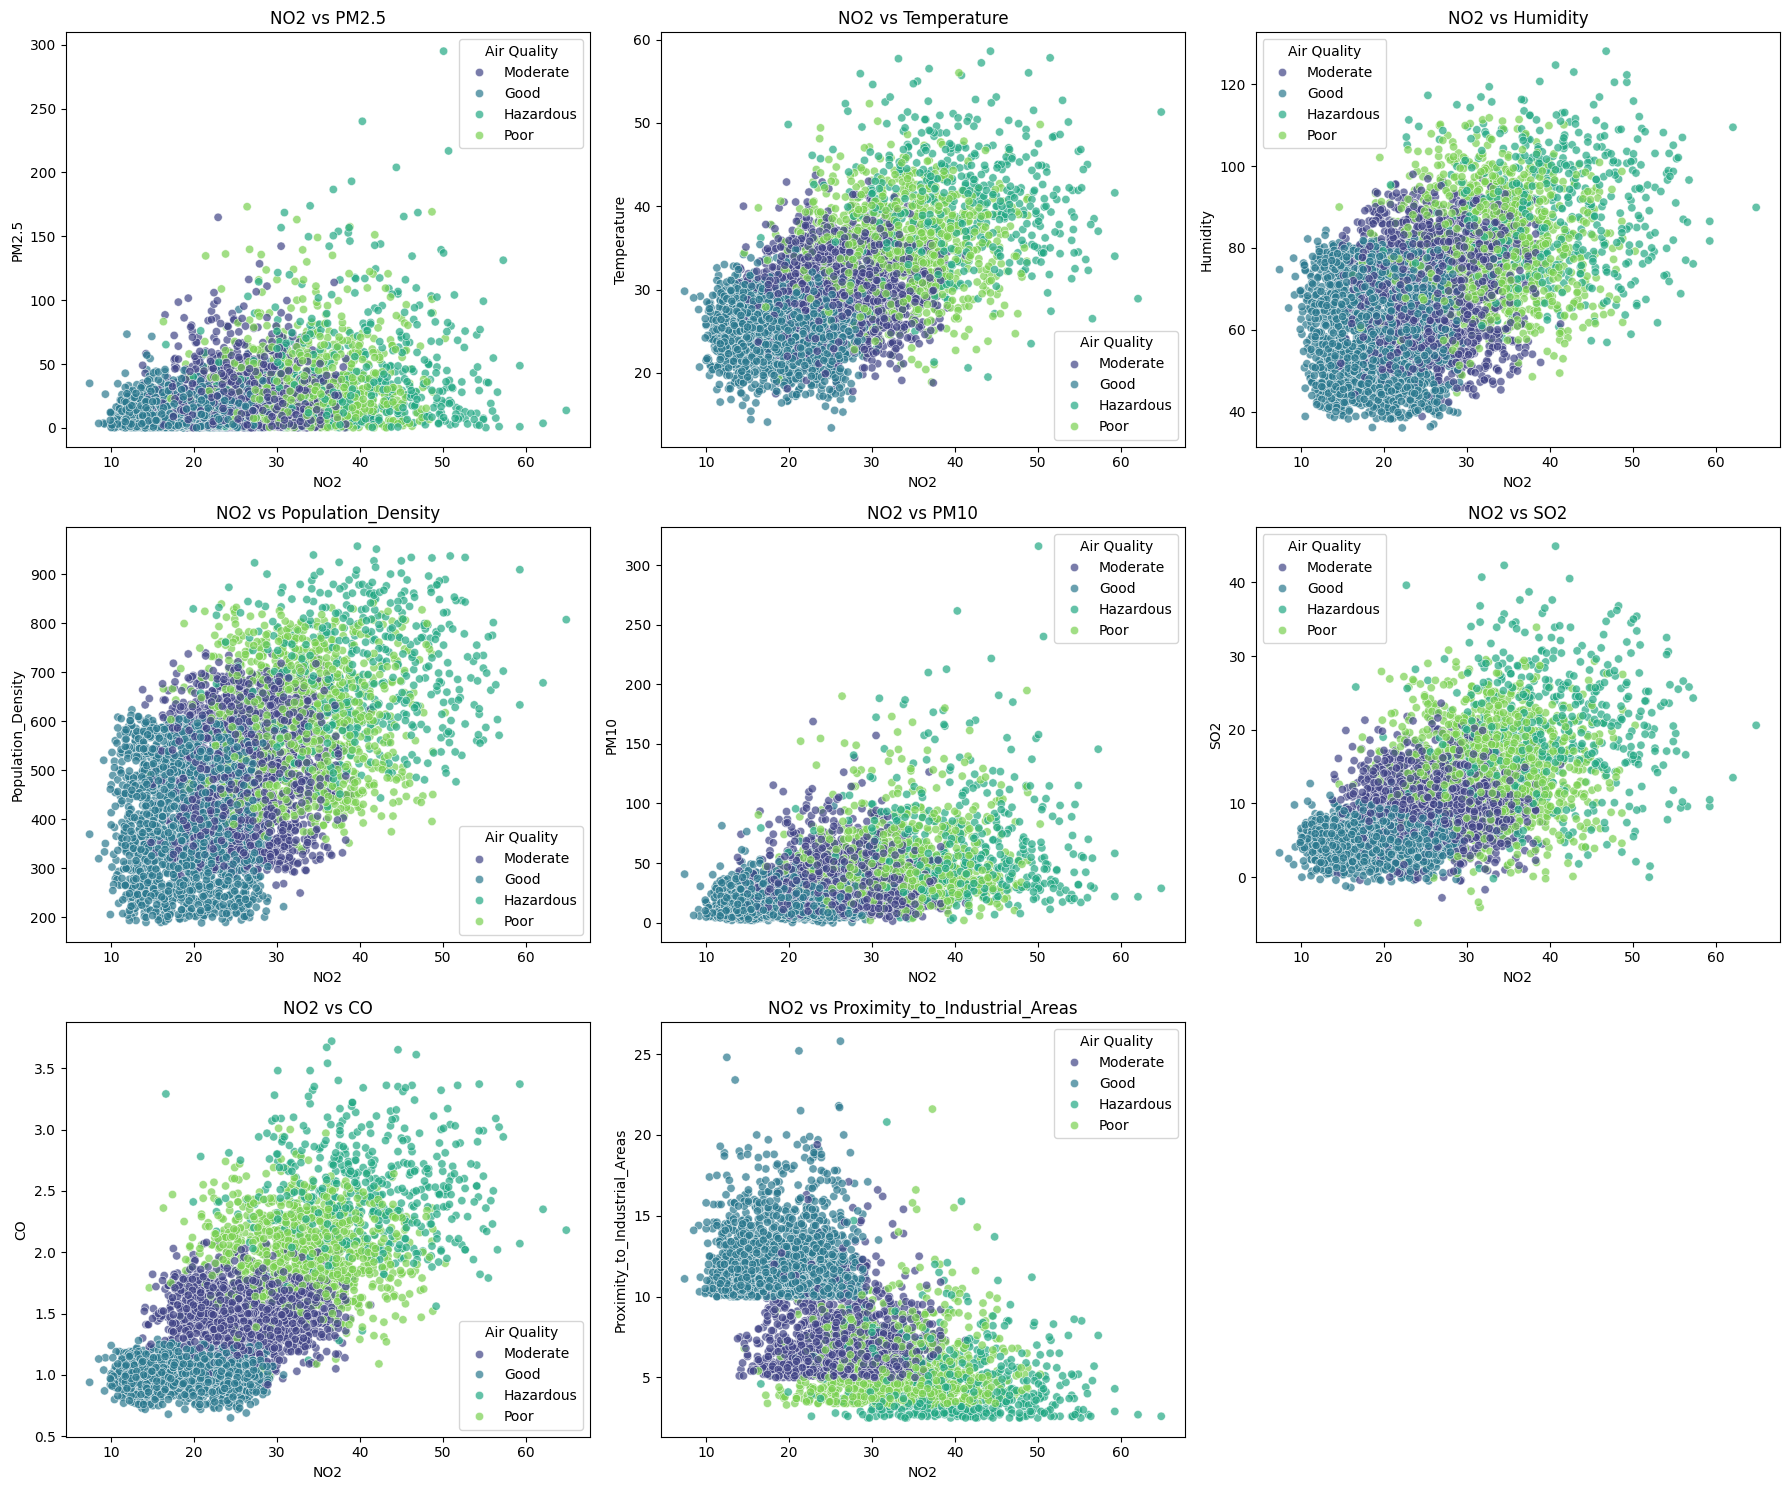

In [ ]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

x_col = 'NO2' if 'NO2' in df.columns else 'N02'

y_vars = [
    'PM2.5', 'Temperature', 'Humidity',
    'Population_Density', 'PM10', 'SO2',
    'CO', 'Proximity_to_Industrial_Areas'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
palette = sns.color_palette("viridis", n_colors=df['Air Quality'].nunique())

for i, y in enumerate(y_vars):
    r, c = divmod(i, 3)
    sns.scatterplot(
        data=df, x=x_col, y=y, hue='Air Quality',
        ax=axes[r][c], alpha=0.7, palette=palette
    )
    axes[r][c].set_title(f'{x_col} vs {y}')

fig.delaxes(axes[2][2])

plt.tight_layout()
plt.show()

These scatter plots display the relationships between NO₂ concentrations and several environmental and pollutant attributes (PM2.5, PM10, CO, SO₂, humidity, temperature, and others).

The color-coded points represent different Air Quality categories. The visible upward trends between NO₂ and other pollutants such as PM2.5 and PM10 indicate strong positive correlations — meaning these variables tend to rise together in polluted conditions.

Such relationships are valuable for identifying multicollinearity, where multiple features convey similar information. This observation supports the need for feature selection or dimensionality reduction during preprocessing to prevent redundancy and improve model efficiency.

---



1-Variable Distributions

Numeric columns: ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas', 'Population_Density']


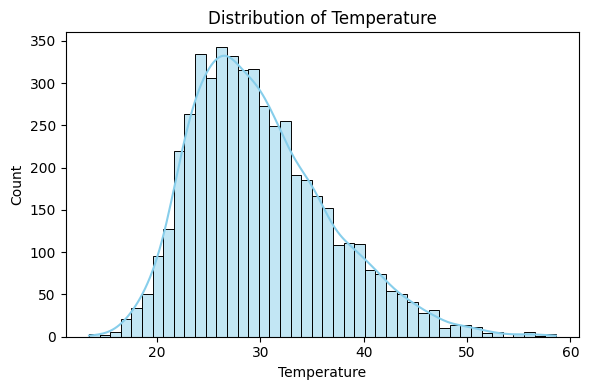

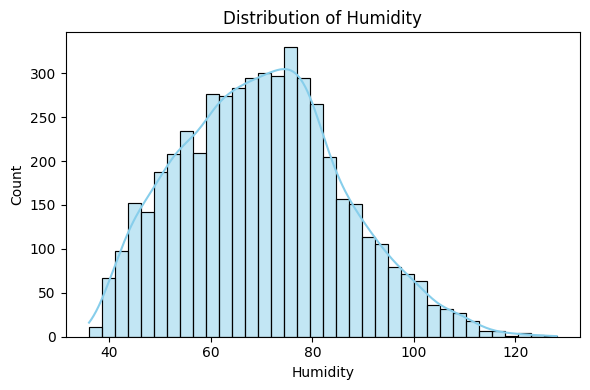

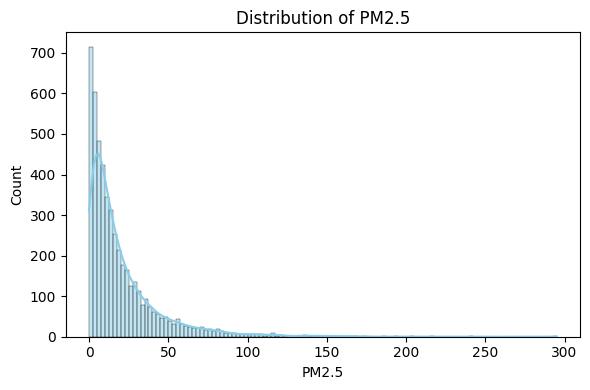

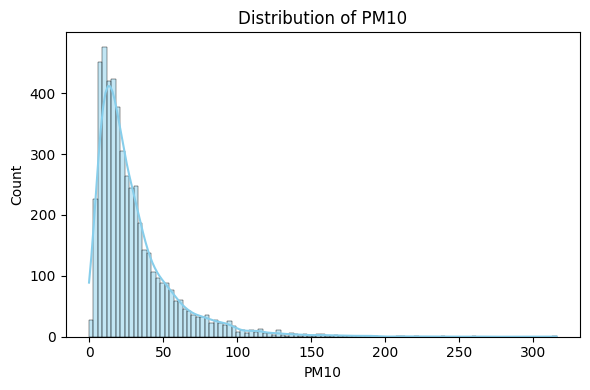

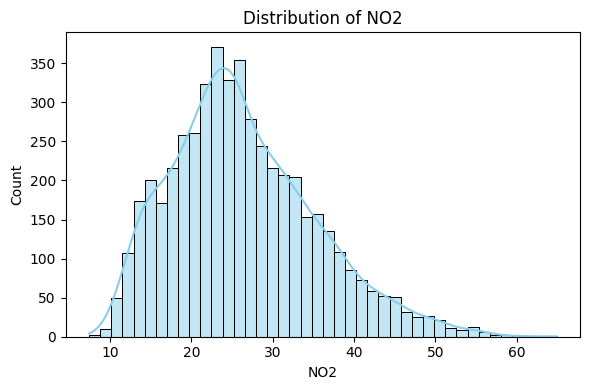

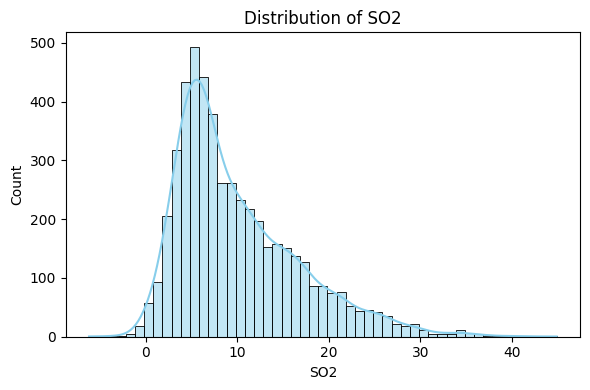

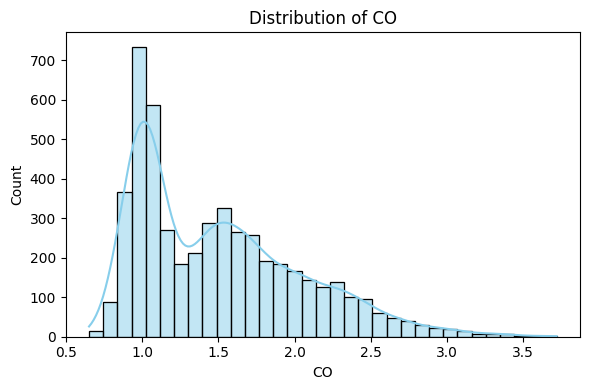

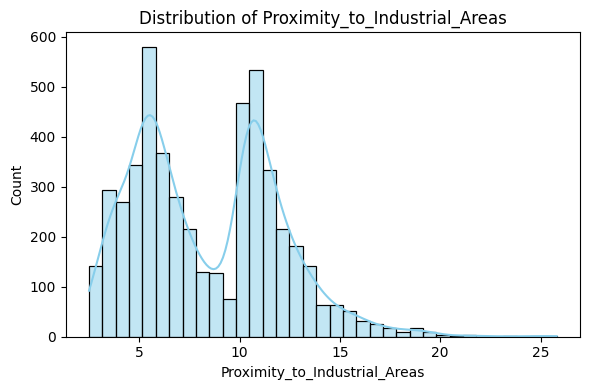

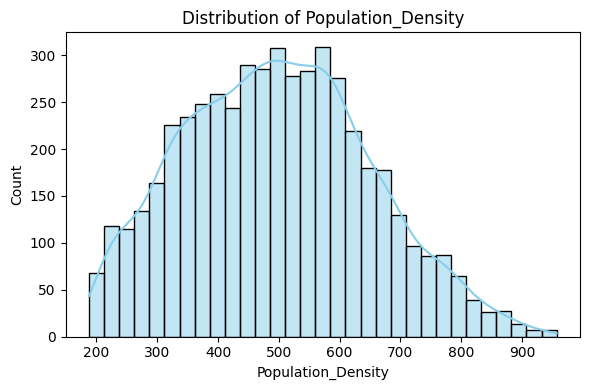

In [ ]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numeric columns:", numeric_cols)


for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


These observations reveal that the dataset contains skewed variables and potential outliers, which means that preprocessing steps such as normalization and outlier handling will be required to improve the data quality before applying data mining techniques.

2-Analyze Missing Values

In [ ]:

missing_count = df.isnull().sum()


missing_percentage = (missing_count / len(df)) * 100


missing_data = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percentage
})


missing_data = missing_data[missing_data['Missing Values'] > 0]
missing_data.sort_values(by='Missing Values', ascending=False)


,Missing Values,Percentage (%)


The results show that there are no missing values in the dataset.
This indicates that the data is complete and consistent, so no imputation or removal of missing records is required at this stage.

3-Statistical Summaries

In [ ]:

stat_summary = df.describe()
stat_summary


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


Most features have large differences between minimum and maximum values, especially PM2.5, PM10, and SO2, which suggests the presence of outliers.


4-Plot showing class label distributions

In [ ]:

df.columns


Index(['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
       'Proximity_to_Industrial_Areas', 'Population_Density', 'Air Quality'],
      dtype='object')

In [ ]:
df.columns.tolist()


['Temperature',
 'Humidity',
 'PM2.5',
 'PM10',
 'NO2',
 'SO2',
 'CO',
 'Proximity_to_Industrial_Areas',
 'Population_Density',
 'Air Quality']

In [ ]:
df['Air Quality'].unique()


array(['Moderate', 'Good', 'Hazardous', 'Poor'], dtype=object)

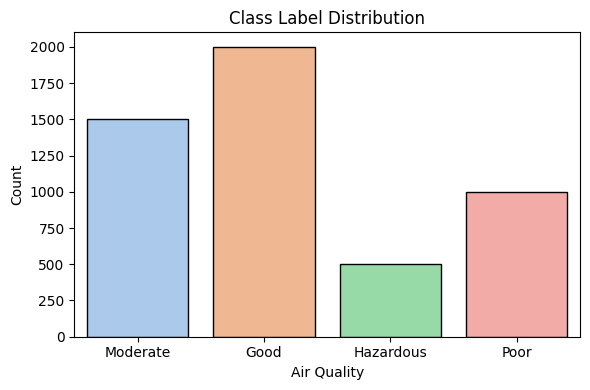

,count
Air Quality,
Good,2000
Moderate,1500
Poor,1000
Hazardous,500


In [ ]:
class_column = 'Air Quality'

plt.figure(figsize=(6,4))
sns.countplot(x=class_column, data=df, palette='pastel', edgecolor='black')
plt.title('Class Label Distribution')
plt.xlabel('Air Quality')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

df[class_column].value_counts()


The class label distribution shows that the majority of the records fall under the Good and Moderate air quality categories, while Poor and Hazardous levels have fewer samples.
This indicates that the dataset is slightly imbalanced, with cleaner air conditions being more frequent than polluted ones.
Such imbalance should be considered in the modeling phase, as it may affect classification performance and require techniques like resampling or class weighting.

# Data Preprocessing
The data preprocessing stage is essential to improve data quality and prepare the dataset for analysis and modeling.
Two preprocessing techniques were applied:
1) Handling missing values using mean for numeric columns and mode for categorical columns.
2) Min–Max normalization to scale numeric features to the [0, 1] range.
Each technique is described with its purpose, method, and the attributes it was applied on.


Handling Missing Values:

Why: Missing values can negatively affect analysis and model performance by introducing bias or errors.

How: Missing numeric values were replaced with the mean of the corresponding column. Missing categorical values were replaced with the most frequent value (mode).
  
Which attributes:All numeric pollutant and weather columns, and any categorical columns such as location or city.


In [ ]:
import numpy as np

print("Missing values BEFORE:\n", df.isna().sum())

num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

for c in cat_cols:
    if df[c].isna().sum() > 0:
        df[c] = df[c].fillna(df[c].mode().iloc[0])

print("\nMissing values AFTER:\n", df.isna().sum())


Missing values BEFORE:
 Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
Air Quality                      0
dtype: int64

Missing values AFTER:
 Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
Air Quality                      0
dtype: int64


Min–Max Normalization

Why: Numeric features often have different scales, which can distort model behavior or reduce accuracy. Normalization scales all values to the same range, ensuring fair comparison between features.

How: The Min–Max normalization formula was applied:
    X_scaled = (X - min) / (max - min)
    
Which attributes: All numeric columns except any target or label columns.

In [ ]:
df_before_norm = df.copy()

num_cols = df.select_dtypes(include='number').columns.tolist()

exclude_cols = []
num_to_scale = [c for c in num_cols if c not in exclude_cols]

df[num_to_scale] = (df[num_to_scale] - df[num_to_scale].min()) / (df[num_to_scale].max() - df[num_to_scale].min())

print("After normalization — min:\n", df[num_to_scale].min().head())
print("\nAfter normalization — max:\n", df[num_to_scale].max().head())


After normalization — min:
 Temperature    0.0
Humidity       0.0
PM2.5          0.0
PM10           0.0
NO2            0.0
dtype: float64

After normalization — max:
 Temperature    1.0
Humidity       1.0
PM2.5          1.0
PM10           1.0
NO2            1.0
dtype: float64
